Epoch 1/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0023 - val_loss: 9.8392e-05
Epoch 2/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.2514e-04 - val_loss: 5.5209e-05
Epoch 3/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.6364e-05 - val_loss: 6.8678e-06
Epoch 4/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 5.6451e-06 - val_loss: 5.3179e-06
Epoch 5/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 4.2066e-06 - val_loss: 4.0277e-06
Epoch 6/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.5430e-06 - val_loss: 3.5136e-06
Epoch 7/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 3.2044e-06 - val_loss: 3.1161e-06
Epoch 8/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2.8530e-06 - val_loss: 2.9028e-06
Epoch 9/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 2.5005e-06 - val_loss: 2.5238e-06
Epoch 10/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.2004e-06 - val_loss: 2.1774e-06
Epoch 11/20
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1.9990e-06 - val_loss: 

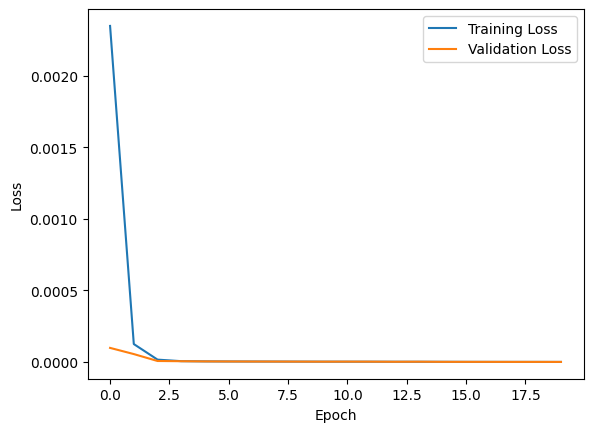

In [3]:


import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Generate data
def generate_data():
    X, y = [], []

    for i in range(1000):
        start = np.random.randint(0, 50)

        seq = [start + j for j in range(6)]

        X.append(seq[:-1])
        y.append(seq[-1])

    return np.array(X)/100.0, np.array(y)/100.0

# Create dataset
X, y = generate_data()

X = X.reshape(1000, 5, 1)

# Build model
model = Sequential([
    SimpleRNN(32, input_shape=(5,1)),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')

# Train model
history = model.fit(
    X, y,
    epochs=20,
    validation_split=0.2,
    verbose=1
)

# Evaluate
loss = model.evaluate(X, y, verbose=0)
print("\nLoss:", loss)

# Predict new sample
test = np.array([[10,11,12,13,14]]) / 100.0
test = test.reshape(1,5,1)

pred = model.predict(test, verbose=0)

print("Predicted Next Value:", pred[0][0] * 100)

# Plot graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()